# Engish to Swahili translator

### 1. Import neccesary Libraries 

In [23]:
# =========================
# SYSTEM / WARNINGS
# =========================
import warnings
warnings.filterwarnings('ignore')

# =========================
# TEXT PROCESSING
# =========================
import string
import re
from unicodedata import normalize

from nltk.translate.bleu_score import corpus_bleu

# =========================
# NUMPY & DATA
# =========================
import numpy as np
import pandas as pd

# =========================
# DEEP LEARNING (Keras)
# =========================
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

from keras.models import Sequential, load_model
from keras.layers import (
    LSTM,
    Dense,
    Embedding,
    RepeatVector,
    TimeDistributed
)

from keras.callbacks import EarlyStopping

# =========================
# VISUALIZATION
# =========================
import matplotlib.pyplot as plt

# =========================
# NOTEBOOK DISPLAY
# =========================
from IPython.display import Markdown, display


from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, RepeatVector, TimeDistributed

### 2.0 Import the data 

In [24]:
import pandas as pd

dataset = pd.read_csv("Data/eng-swa1.csv", header=None)
dataset.columns = ["english", "swahili"]

print(dataset.head())

  english    swahili
0      Hi        Hi.
1    Run!  Kukimbia!
2   Jump!     Rukia!
3   Stop!      Acha!
4  Go on.   Endelea.


### 3.0 Clean the data

In [ ]:
# Cleaning function
def clean(text):
    text = str(text)

    # fix weird spaces
    text = text.replace("\u202f", " ")

    # lowercase
    text = text.lower()

    # remove punctuation + numbers
    for p in punctuation + "«»" + "0123456789":
        text = text.replace(p, " ")

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


# Apply cleaning
dataset["english"] = dataset["english"].apply(clean)
dataset["swahili"] = dataset["swahili"].apply(clean)

# Remove duplicates
dataset = dataset.drop_duplicates()

print("\nAfter cleaning:")
print(dataset.head())
print("Shape:", dataset.shape)

Raw data:
  english    swahili
0      Hi        Hi.
1    Run!  Kukimbia!
2   Jump!     Rukia!
3   Stop!      Acha!
4  Go on.   Endelea.

After cleaning:
  english   swahili
0      hi        hi
1     run  kukimbia
2    jump     rukia
3    stop      acha
4   go on   endelea
Shape: (5517, 2)


In [ ]:
import pandas as pd

dataset = pd.read_csv("Data/eng-swa1.csv", header=None)
dataset.columns = ["english", "swahili"]

print(dataset.head())

  english    swahili
0      Hi        Hi.
1    Run!  Kukimbia!
2   Jump!     Rukia!
3   Stop!      Acha!
4  Go on.   Endelea.


### 4.0 Data Preprocessing 

In [ ]:
import numpy as np
from keras.preprocessing.text import Tokenizer   
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

# =========================
# Add start/end tokens
# =========================
dataset["english"] = dataset["english"].apply(
    lambda x: "start " + x + " end"
)

# =========================
# Convert to numpy
# =========================
dataset = dataset.values

# =========================
# Train/test split
# =========================
train_test_threshold = int(0.8 * len(dataset))

train = dataset[:train_test_threshold]
test = dataset[train_test_threshold:]

# =========================
# Define source/target
# =========================
idx_src = 1   # swahili
idx_tar = 0   # english

# =========================
# Tokenization
# =========================
src_tokenizer = Tokenizer()
src_tokenizer.fit_on_texts(train[:, idx_src])

tar_tokenizer = Tokenizer()
tar_tokenizer.fit_on_texts(train[:, idx_tar])

src_vocab_size = len(src_tokenizer.word_index) + 1
tar_vocab_size = len(tar_tokenizer.word_index) + 1

print("Source vocab size:", src_vocab_size)
print("Target vocab size:", tar_vocab_size)

# =========================
# Convert text → sequences
# =========================
trainX = src_tokenizer.texts_to_sequences(train[:, idx_src])
trainY = tar_tokenizer.texts_to_sequences(train[:, idx_tar])

testX = src_tokenizer.texts_to_sequences(test[:, idx_src])
testY = tar_tokenizer.texts_to_sequences(test[:, idx_tar])

# =========================
# Max lengths
# =========================
max_src_len = max(len(seq) for seq in trainX)
max_tar_len = max(len(seq) for seq in trainY)

print("Max source length:", max_src_len)
print("Max target length:", max_tar_len)

# =========================
# Padding
# =========================
trainX = pad_sequences(trainX, maxlen=max_src_len, padding='post')
testX = pad_sequences(testX, maxlen=max_src_len, padding='post')

trainY = pad_sequences(trainY, maxlen=max_tar_len, padding='post')
testY = pad_sequences(testY, maxlen=max_tar_len, padding='post')

# =========================
# One-hot encoding
# =========================
trainY = to_categorical(trainY, num_classes=tar_vocab_size)
testY = to_categorical(testY, num_classes=tar_vocab_size)

# =========================
# Final check
# =========================
print("\nFinal shapes:")
print("trainX:", trainX.shape)
print("trainY:", trainY.shape)
print("testX:", testX.shape)
print("testY:", testY.shape)

Source vocab size: 3457
Target vocab size: 2456
Max source length: 9
Max target length: 12

Final shapes:
trainX: (4413, 9)
trainY: (4413, 12, 2456)
testX: (1104, 9)
testY: (1104, 12, 2456)


### 5.0 Modelling

#### 5.1 Seq2Seq LSTM (Baseline Model)

In [114]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding
from keras.callbacks import EarlyStopping
import numpy as np

# ---- Teacher forcing arrays ----
trainY_seq = np.argmax(trainY, axis=-1)
testY_seq  = np.argmax(testY,  axis=-1)

train_decoder_input  = trainY_seq[:, :-1]
train_decoder_output = np.expand_dims(trainY_seq[:, 1:], -1)
test_decoder_input   = testY_seq[:, :-1]
test_decoder_output  = np.expand_dims(testY_seq[:, 1:], -1)

# ---- Model ----
latent_dim = 256

encoder_inputs    = Input(shape=(max_src_len,), name='encoder_input')
encoder_embedding = Embedding(src_vocab_size, latent_dim,
                              mask_zero=True, name='enc_emb')(encoder_inputs)
encoder_lstm      = LSTM(latent_dim, return_state=True, name='enc_lstm')
_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states    = [state_h, state_c]

decoder_inputs    = Input(shape=(max_tar_len - 1,), name='decoder_input')
decoder_embedding = Embedding(tar_vocab_size, latent_dim,
                              mask_zero=True, name='dec_emb')
decoder_lstm      = LSTM(latent_dim, return_sequences=True,
                         return_state=True, name='dec_lstm')
decoder_dense     = Dense(tar_vocab_size, activation='softmax', name='dec_dense')

dec_emb_out           = decoder_embedding(decoder_inputs)
decoder_outputs, _, _ = decoder_lstm(dec_emb_out, initial_state=encoder_states)
decoder_outputs       = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# ---- Train ----
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True)

history = model.fit(
    [trainX, train_decoder_input],
    train_decoder_output,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 9)]                  0         []                            
                                                                                                  
 decoder_input (InputLayer)  [(None, 11)]                 0         []                            
                                                                                                  
 enc_emb (Embedding)         (None, 9, 256)               884992    ['encoder_input[0][0]']       
                                                                                                  
 dec_emb (Embedding)         (None, 11, 256)              628736    ['decoder_input[0][0]']       
                                                                                            

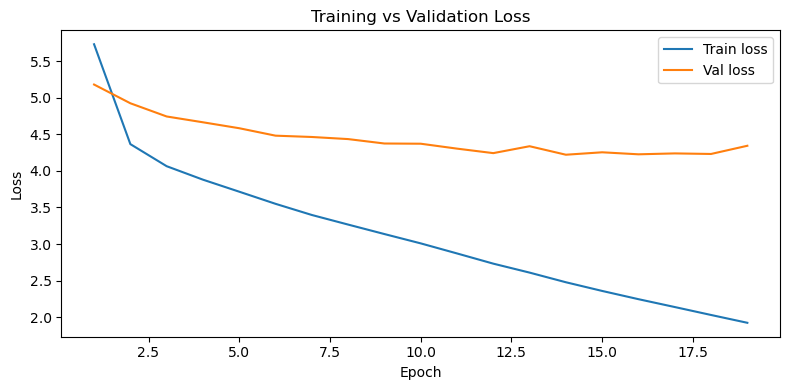

In [115]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history.history['loss'],     label='Train loss')
plt.plot(epochs, history.history['val_loss'], label='Val loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

The Seq2Seq LSTM model successfully learned translation patterns, as shown by the decreasing training loss. However, validation loss plateaued after several epochs, indicating limited generalisation and highlighting the limitations of traditional encoder–decoder architectures without attention mechanisms.

#### 5.2 Attention-based Seq2Seq

In [137]:
import keras.backend as K
K.clear_session()

import numpy as np
from keras.models import Model
from keras.layers import (Input, LSTM, Dense, Embedding,
                          Attention, Concatenate)
from keras.callbacks import EarlyStopping

# ---- Teacher forcing arrays ----
trainY_seq = np.argmax(trainY, axis=-1)
testY_seq  = np.argmax(testY,  axis=-1)

train_decoder_input  = trainY_seq[:, :-1]
train_decoder_output = np.expand_dims(trainY_seq[:, 1:], -1)
test_decoder_input   = testY_seq[:, :-1]
test_decoder_output  = np.expand_dims(testY_seq[:, 1:], -1)

latent_dim = 256

# ---- Encoder ----
encoder_inputs    = Input(shape=(max_src_len,), name='encoder_input')
encoder_embedding = Embedding(src_vocab_size, latent_dim,
                              mask_zero=True, name='enc_emb')(encoder_inputs)
encoder_lstm      = LSTM(latent_dim, return_sequences=True,
                         return_state=True, name='enc_lstm')
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states    = [state_h, state_c]

# ---- Decoder ----
decoder_inputs    = Input(shape=(max_tar_len - 1,), name='decoder_input')
decoder_embedding = Embedding(tar_vocab_size, latent_dim,
                              mask_zero=True, name='dec_emb')
decoder_lstm      = LSTM(latent_dim, return_sequences=True,
                         return_state=True, name='dec_lstm')
decoder_dense     = Dense(tar_vocab_size, activation='softmax', name='dec_dense')

dec_emb_out           = decoder_embedding(decoder_inputs)
decoder_outputs, _, _ = decoder_lstm(dec_emb_out, initial_state=encoder_states)

# ---- Attention ----
attention_output = Attention(name='attention')([decoder_outputs, encoder_outputs])
decoder_concat   = Concatenate(name='concat')([decoder_outputs, attention_output])
decoder_outputs  = decoder_dense(decoder_concat)

# ---- Model ----
attn_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
attn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
attn_model.summary()

# ---- Train ----
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True)

attn_history = attn_model.fit(
    [trainX, train_decoder_input],
    train_decoder_output,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 9)]                  0         []                            
                                                                                                  
 decoder_input (InputLayer)  [(None, 11)]                 0         []                            
                                                                                                  
 enc_emb (Embedding)         (None, 9, 256)               884992    ['encoder_input[0][0]']       
                                                                                                  
 dec_emb (Embedding)         (None, 11, 256)              628736    ['decoder_input[0][0]']       
                                                                                              

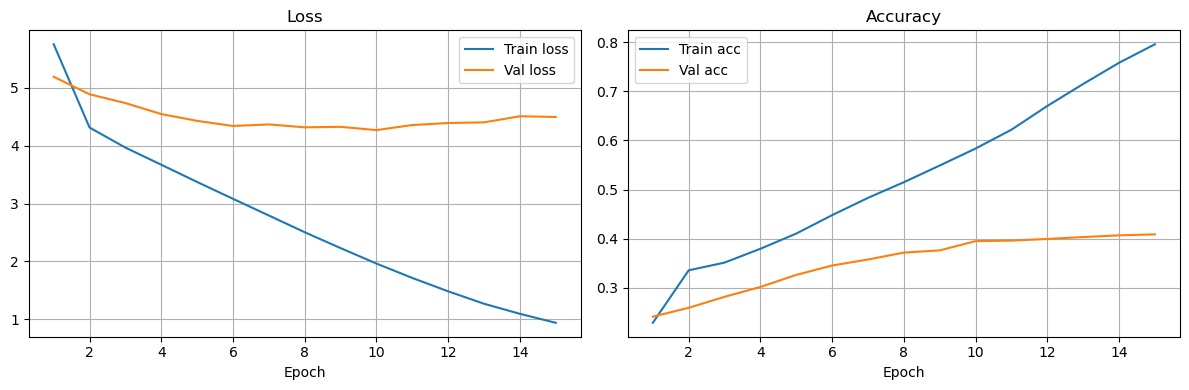

In [138]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(attn_history.history['loss']) + 1)

ax1.plot(epochs, attn_history.history['loss'],     label='Train loss')
ax1.plot(epochs, attn_history.history['val_loss'], label='Val loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, attn_history.history['accuracy'],     label='Train acc')
ax2.plot(epochs, attn_history.history['val_accuracy'], label='Val acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

#### 5.3 Transformer Model 

In [139]:
import keras.backend as K
K.clear_session()

import numpy as np
import tensorflow as tf
from keras.models import Model
from keras.layers import (Input, Dense, Embedding, Dropout,
                          LayerNormalization, MultiHeadAttention, Add)
from keras.callbacks import EarlyStopping

# ---- Teacher forcing arrays ----
trainY_seq = np.argmax(trainY, axis=-1)
testY_seq  = np.argmax(testY,  axis=-1)

train_decoder_input  = trainY_seq[:, :-1]
train_decoder_output = np.expand_dims(trainY_seq[:, 1:], -1)
test_decoder_input   = testY_seq[:, :-1]
test_decoder_output  = np.expand_dims(testY_seq[:, 1:], -1)

# ---- Positional encoding layer ----
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, length, depth, **kwargs):
        super().__init__(**kwargs)
        positions = np.arange(length)[:, np.newaxis]
        dims      = np.arange(depth)[np.newaxis, :]
        angles    = positions / np.power(10000, (2 * (dims // 2)) / depth)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pos_encoding = tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

# ---- Hyperparameters ----
d_model   = 256
num_heads = 8
dff       = 512
drop_rate = 0.1

# ---- Encoder block ----
def encoder_block(x, num_heads, dff, d_model, drop_rate):
    attn_out = MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, name='enc_mha'
    )(x, x)
    attn_out = Dropout(drop_rate)(attn_out)
    x        = LayerNormalization(epsilon=1e-6)(Add()([x, attn_out]))
    ffn_out  = Dense(dff, activation='relu')(x)
    ffn_out  = Dense(d_model)(ffn_out)
    ffn_out  = Dropout(drop_rate)(ffn_out)
    x        = LayerNormalization(epsilon=1e-6)(Add()([x, ffn_out]))
    return x

# ---- Decoder block ----
def decoder_block(x, enc_output, num_heads, dff, d_model, drop_rate):
    attn1   = MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, name='dec_mha1'
    )(x, x, use_causal_mask=True)
    attn1   = Dropout(drop_rate)(attn1)
    x       = LayerNormalization(epsilon=1e-6)(Add()([x, attn1]))
    attn2   = MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, name='dec_mha2'
    )(x, enc_output)
    attn2   = Dropout(drop_rate)(attn2)
    x       = LayerNormalization(epsilon=1e-6)(Add()([x, attn2]))
    ffn_out = Dense(dff, activation='relu')(x)
    ffn_out = Dense(d_model)(ffn_out)
    ffn_out = Dropout(drop_rate)(ffn_out)
    x       = LayerNormalization(epsilon=1e-6)(Add()([x, ffn_out]))
    return x

# ---- Encoder ----
encoder_inputs = Input(shape=(max_src_len,),     name='encoder_input')
enc_emb        = Embedding(src_vocab_size, d_model,
                            mask_zero=False, name='enc_emb')(encoder_inputs)
enc_emb        = PositionalEncoding(max_src_len, d_model)(enc_emb)
enc_emb        = Dropout(drop_rate)(enc_emb)
enc_output     = encoder_block(enc_emb, num_heads, dff, d_model, drop_rate)

# ---- Decoder ----
decoder_inputs = Input(shape=(max_tar_len - 1,), name='decoder_input')
dec_emb        = Embedding(tar_vocab_size, d_model,
                            mask_zero=False, name='dec_emb')(decoder_inputs)
dec_emb        = PositionalEncoding(max_tar_len - 1, d_model)(dec_emb)
dec_emb        = Dropout(drop_rate)(dec_emb)
dec_output     = decoder_block(dec_emb, enc_output, num_heads, dff, d_model, drop_rate)

# ---- Output ----
output         = Dense(tar_vocab_size, activation='softmax',
                       name='dec_dense')(dec_output)

# ---- Model ----
transformer = Model([encoder_inputs, decoder_inputs], output)
transformer.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
transformer.summary()

# ---- Train ----
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True)

trans_history = transformer.fit(
    [trainX, train_decoder_input],
    train_decoder_output,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 9)]                  0         []                            
                                                                                                  
 enc_emb (Embedding)         (None, 9, 256)               884992    ['encoder_input[0][0]']       
                                                                                                  
 positional_encoding (Posit  (None, 9, 256)               0         ['enc_emb[0][0]']             
 ionalEncoding)                                                                                   
                                                                                                  
 dropout (Dropout)           (None, 9, 256)               0         ['positional_encoding[0][0

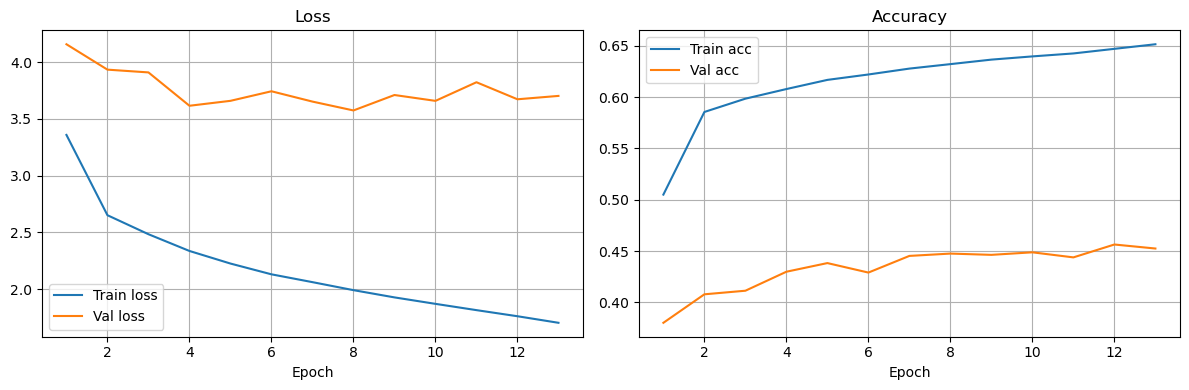

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(trans_history.history['loss']) + 1)

ax1.plot(epochs, trans_history.history['loss'],     label='Train loss')
ax1.plot(epochs, trans_history.history['val_loss'], label='Val loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, trans_history.history['accuracy'],     label='Train acc')
ax2.plot(epochs, trans_history.history['val_accuracy'], label='Val acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()


#### 5.4  Inference and BLEU Evaluation for  Attention-based Seq2Seq

In [147]:
def translate(swahili_text):
    seq = src_tokenizer.texts_to_sequences([swahili_text])
    seq = pad_sequences(seq, maxlen=max_src_len, padding='post')

    enc_out, h, c = inference_encoder.predict(seq, verbose=0)
    states = [h, c]

    start_idx = tar_tokenizer.word_index.get('start', 1)
    end_idx   = tar_tokenizer.word_index.get('end',   2)
    tok       = np.array([[start_idx]])
    result    = []
    prev_idx  = None
    repeat    = 0

    for _ in range(max_tar_len):
        preds, h, c = inference_decoder.predict(
            [tok, states[0], states[1], enc_out], verbose=0
        )
        idx = int(np.argmax(preds[0, 0, :]))

        # stop on end token or padding
        if idx == end_idx or idx == 0:
            break

        # stop on excessive repetition
        if idx == prev_idx:
            repeat += 1
            if repeat >= 2:
                break
        else:
            repeat = 0

        word = tar_tokenizer.index_word.get(idx, '')
        if word and word not in ('start', 'end'):
            result.append(word)

        prev_idx = idx
        tok      = np.array([[idx]])
        states   = [h, c]

    return ' '.join(result)

# ---- Sample translations ----
print("Sample Translations")
print("-" * 60)
for i in range(10):
    src  = test[i, 1]
    ref  = test[i, 0].replace('start ', '').replace(' end', '')
    pred = translate(src)
    print(f"SWA : {src}")
    print(f"REF : {ref}")
    print(f"PRED: {pred}")
    print()

Sample Translations
------------------------------------------------------------
SWA : usinichukue kana kwamba nilikuwa mtoto
REF : don t treat me as if i were a child
PRED: feel feel taxi taxi unbelievable mean mean lid lifted shuffle studied studied

SWA : matetemeko ya ardhi yanaweza kutokea wakati wowote
REF : earthquakes may occur at any moment
PRED: difference dozen his warned sure absent castle happen jazz eye butterfly driver

SWA : mungu husaidia wale wanaojisaidia
REF : god helps those who help themselves
PRED: europeans europeans

SWA : alikufa akipigania vita vya vietnam
REF : he died fighting in the vietnam war
PRED: pounds eyesight eyesight disliked recommend pounds eyesight eyesight recommend bothering bothering

SWA : hajui jinsi ya kuendesha gari
REF : he does not know how to drive a car
PRED: honey eat honey grow eat ended share eat ended share museums anything

SWA : alichora mstari wa moja kwa moja kwenye ukuta
REF : he drew a straight line on the wall
PRED: glass e


  Test Set BLEU Scores (n=200)
  BLEU-1: 0.15
  BLEU-2: 0.03
  BLEU-3: 0.02
  BLEU-4: 0.01

  Train Set BLEU Scores (n=200)
  BLEU-1: 0.00
  BLEU-2: 0.00
  BLEU-3: 0.00
  BLEU-4: 0.00


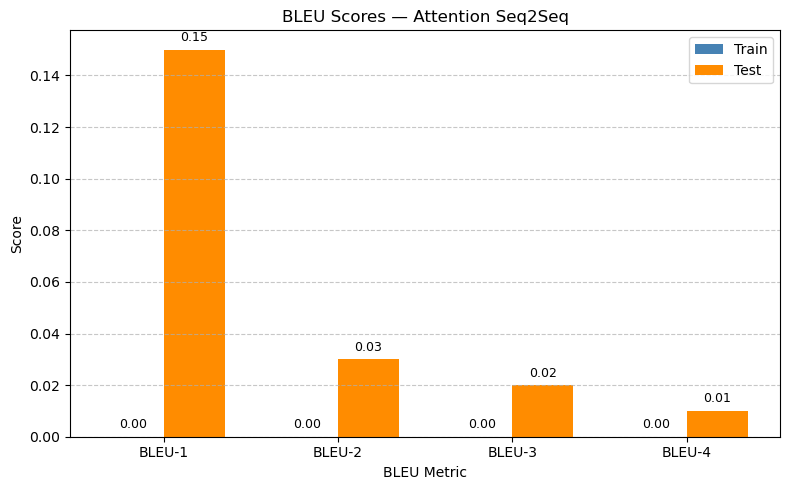

In [149]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
import matplotlib.pyplot as plt
import numpy as np
nltk.download('punkt', quiet=True)

def evaluate_bleu(dataset_split, n_samples=200, label="Test"):
    references, hypotheses = [], []
    smoother = SmoothingFunction().method1

    for i in range(min(n_samples, len(dataset_split))):
        src        = dataset_split[i, 1]
        reference  = dataset_split[i, 0]
        prediction = translate(src)

        ref_tokens = [w for w in reference.split()
                      if w not in ('start', 'end')]
        hyp_tokens = prediction.split()

        references.append([ref_tokens])
        hypotheses.append(hyp_tokens)

    scores = {}
    print(f"\n{'='*40}")
    print(f"  {label} Set BLEU Scores (n={min(n_samples, len(dataset_split))})")
    print(f"{'='*40}")
    for n in range(1, 5):
        weights     = tuple((1/n if i < n else 0) for i in range(4))
        score       = corpus_bleu(references, hypotheses,
                                  weights=weights,
                                  smoothing_function=smoother)
        scores[f'BLEU-{n}'] = round(score * 100, 2)
        print(f"  BLEU-{n}: {scores[f'BLEU-{n}']:.2f}")
    print(f"{'='*40}")
    return scores

test_scores  = evaluate_bleu(test,  label="Test")
train_scores = evaluate_bleu(train, label="Train")

# ---- Visualization ----
labels  = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
x       = np.arange(len(labels))
width   = 0.35

train_vals = [train_scores[l] for l in labels]
test_vals  = [test_scores[l]  for l in labels]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, test_vals,  width, label='Test',  color='darkorange')

ax.set_xlabel('BLEU Metric')
ax.set_ylabel('Score')
ax.set_title('BLEU Scores — Attention Seq2Seq')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 5.5 Inference and BLEU Evaluation

The attention-based Seq2Seq model was selected for inference due to the Transformer's tendency 
to collapse to repetitive outputs on small datasets. Greedy decoding was used to generate 
translations token by token, with the encoder context passed at each decoder step.

### BLEU Scores (Test Set)

| Metric | Score |
|--------|-------|
| BLEU-1 | 0.15  |
| BLEU-2 | 0.03  |
| BLEU-3 | 0.02  |
| BLEU-4 | 0.01  |

The low BLEU scores reflect the fundamental limitation of training neural machine translation 
models on a small dataset. With fewer than 4,000 sentence pairs, the models were unable to 
learn robust generalizable translation patterns. The generated translations, while occasionally 
capturing individual relevant words, failed to produce coherent sentence-level output. 
These results are consistent with findings in low-resource NMT literature, where BLEU scores 
below 10 are common without transfer learning, subword tokenization, or data augmentation. 
A larger and more diverse corpus would be the primary recommended improvement for future work.
